## Analysis of The Chicago Transit Authority Bus System

This workbook analyses the accuracy of bus arrival times of buses throughout the city of Chicago using the city's [open data API resource.](https://www.transitchicago.com/developers/bustracker/) This script is preceeded by the Pull API script, which collects the data from the CTA open data API that shares live predictions of train arrivals throughout the city. Since Mid-January 2025, this API has been collecting data to understand the accuracy of bus arrival estimates at various times throughout the day. This data is consistently undated, with new files added each hour between 6 AM and 10 PM. as the data currently stands the estimates given for train arrival are accurate approximately 85% of the time (p <.1). The logistic regression proformed in this Notebook seeks to better understand the given factors that tend to make busses deviate from their expected time of arrival.

In [17]:
import pandas as pd
from pandas import Series, DataFrame
import requests
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from pandas import json_normalize
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(font_scale=1.5)
import numpy as np

from pylab import rcParams
rcParams['figure.figsize'] = 20, 10
from sklearn.linear_model import LogisticRegression as Model
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def get_files_from_folder(path):
    """Gets a list of all files in the specified folder."""

    rte_dat = pd.DataFrame()
    for entry in os.listdir(path):
        full_path = os.path.join(path, entry)
        if full_path.endswith('.csv'):
            data_piece = pd.read_csv(full_path)
            rte_dat = pd.concat([rte_dat, data_piece], ignore_index=True)
    return rte_dat



def get_route_timinginfo(url, key, inner, params = None, pdf = pd.DataFrame()):
    #make url
    basic_url = url + key
    if params !=None:
        for inp in params:
            basic_url += '&'+ inp
   
    basic_url += '&format=json'
    response = requests.get(basic_url)
    response.raise_for_status()  # Check for errors
    data = response.json()
    
    try:
        if pdf.empty:
            df1 = pd.json_normalize(data['bustime-response'][inner][0]['pt'])
            df1['direct'] = data['bustime-response'][inner][0]['rtdir']
            df2 = pd.json_normalize(data['bustime-response'][inner][1]['pt'])
            df2['direct'] = data['bustime-response'][inner][1]['rtdir']
            df= pd.concat([df1, df2], ignore_index=True)
            print("created")
            return df
        else:
            df1 = pd.json_normalize(data['bustime-response'][inner][0]['pt'])
            df1['direct'] = data['bustime-response'][inner][0]['rtdir']
            df2 = pd.json_normalize(data['bustime-response'][inner][1]['pt'])
            df2['direct'] = data['bustime-response'][inner][1]['rtdir']
            dfa= pd.concat([pdf, df1], ignore_index=True)
            df= pd.concat([pdf, df2], ignore_index=True)
            print("add on")
            return df
        
    except IndexError:
        if pdf.empty:
            print("first one, no dir")
            return df1
        else: 
            df = pd.concat([pdf, df1], ignore_index=True)
            print("another")
            return df
    except:
        edf = pd.json_normalize(data['bustime-response']['error'])
        print(edf['msg'])
        return pdf

### Data Processing
The cells below take in live data as well as route information used for data analysis.

In [2]:
key = key = '?key=XHc2nqbXM7sFJk7D9ZwCjZGGn'

patterns_url = 'http://www.ctabustracker.com/bustime/api/v2/getpatterns'

live_data = get_files_from_folder('live_data')

route_info = pd.DataFrame()
for rt in live_data['rt'].unique():
    route_info = get_route_timinginfo(patterns_url, key, 'ptr', ['rt='+str(rt)], route_info)
    print(len(route_info))
    #route_info = route_info.sort_values(by = ['pdist'], ascending=True, inplace=False, kind='quicksort', na_position='last', ignore_index=True, key=None)

route_info = route_info[route_info['typ'] == 'S']
route_info = route_info.reset_index(drop=True)

#route_info = route_info.sort('rt').sort('rtdir').sort('dstop')
a = 0
c = 1
seq = [0 for d in range(len(route_info))]
while a < len(route_info)-1:
    
    seq[a]= c
    if (route_info['direct'][a] != route_info['direct'][a+1]) & (route_info['pdist'][a+1] == 0):
        c=1
    else:
        c+=1
    
    a+=1
seq[a]= c
route_info['seq'] = seq

created
475
add on
738
add on
861
add on
1212
add on
1488
add on
1563
add on
1922
add on
2120
another
2201
add on
2402
add on
2512
add on
3175
add on
3368
add on
3697
add on
3973
add on
4357
add on
4606
add on
4719
add on
5224
add on
5618
add on
5925
add on
6273
add on
6518
add on
6881
another
6920
add on
7358
add on
7512
add on
7871
add on
8250
add on
8393
add on
8658
add on
8858
add on
9110
add on
9386
add on
9488
add on
9681
add on
10042
add on
10226
add on
10411
another
10466
add on
10664
add on
10967
add on
11139
add on
11402
another
11567
add on
11912
add on
12315
add on
12794
add on
13169
add on
13325
add on
13651
add on
13734
add on
14183
add on
14358
add on
14709
add on
15120
add on
15327
add on
15429
add on
15635
add on
15844
add on
16045
add on
16290
add on
16647
add on
16803
add on
17098
add on
17389
add on
17600
add on
17813
add on
18064
add on
18342
add on
18633
add on
18747
add on
18868
another
19071
add on
19146
add on
19495
add on
19755
add on
20159
add on
20395
add on

In [3]:
info_join = route_info[["seq", 'lat', 'lon', "stpid", 'stpnm', "pdist"]]
info_join['stpid'] = info_join['stpid'].astype(int)
live_data['stpid'] = live_data['stpid'].astype(int)
rte_full = pd.merge(info_join, live_data, on = 'stpid', how = 'inner')

C:\Users\jacks\AppData\Local\Temp\ipykernel_24008\1000049766.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_join['stpid'] = info_join['stpid'].astype(int)


### Data Analysis 
After processing the data, it appears that the given ubss arrival time is accurate 85% of the time, with about 15 of each 100 buss arrivals are innaccurate. These calculations came from checking the tracking API at the time predicted to check if the assigned bus has already arrived or is eminent. Arrival times that were before the time an entry was checked were removed from the dataset (approximately 100 entries). Next logistic regression will attempt to discover other variables that effect the accuracy of arrival times. If these variables do not predict the accuracy of predicted times, more research is likely warrented into how other factors such as traffic patterns, rider traffic, and weather patterns.

In [4]:
rte_full.head()


,seq,lat,lon,stpid,stpnm_x,pdist,tmstmp,typ,stpnm_y,vid,dstp,rt,rtdd,rtdir,des,prdtm,tablockid,tatripid,origtatripno,dly,prdctdn,zone,crt_prd,dep_time
0,1,41.901839,-87.77507,1970,Division & Austin Terminal,0.0,20250124 16:20,D,Division & Austin Terminal,8143,0,70,70,Eastbound,Walton & Dearborn,2025-01-24 16:24:00,70 -801,88364466,259624072,False,4,NaN,True,2025-01-24 16:20:00
1,1,41.901839,-87.77507,1970,Division & Austin Terminal,0.0,20250124 16:19,D,Division & Austin Terminal,2019,1302,70,70,Eastbound,Walton & Dearborn,2025-01-24 16:37:00,70 -807,88364467,259624073,False,16,NaN,True,2025-01-24 16:20:00
2,1,41.901839,-87.77507,1970,Division & Austin Terminal,0.0,20250124 16:20,D,Division & Austin Terminal,8555,19934,70,70,Eastbound,Pulaski,2025-01-24 16:46:00,70 -808,88383451,262195493,False,26,NaN,True,2025-01-24 16:20:00
3,1,41.901839,-87.77507,1970,Division & Austin Terminal,0.0,20250128 10:39,D,Division & Austin Terminal,8588,0,70,70,Eastbound,Walton & Dearborn,2025-01-28 10:44:00,70 -810,88364346,259624041,False,3,NaN,True,2025-01-28 10:55:00
4,1,41.901839,-87.77507,1970,Division & Austin Terminal,0.0,20250128 10:39,D,Division & Austin Terminal,8684,0,70,70,Eastbound,Walton & Dearborn,2025-01-28 10:56:00,72 -804,88364347,259624042,False,15,NaN,True,2025-01-28 11:10:00


In [5]:
rte_full["prdtm"] = pd.to_datetime(rte_full["prdtm"])
rte_full["dep_time"] = pd.to_datetime(rte_full["dep_time"])

# Compute time difference
rte_full['delta'] = rte_full["dep_time"] - rte_full["prdtm"]

# Create subset
rte_full = rte_full[(rte_full['crt_prd'] == False) | (rte_full['delta'] < pd.Timedelta('4 minutes'))]

rte_full.loc[rte_full['prdctdn'] == "DUE", 'prdctdn'] = "0"
rte_full.loc[rte_full['prdctdn'] == "DLY", 'prdctdn'] = "-1"
rte_full['prdctdn'] = rte_full['prdctdn'].astype(int)


In [6]:
print("average on time percentage for busses on route 70 is " + str(sum(rte_full['crt_prd'])/len(rte_full)*100)+ '%')


average on time percentage for busses on route 70 is 85.7722382268211%


The average on-time percentage for busses recorded was 84.2%. This is consistent with the expected accuracy rate of approximately 85% .The graph below shows the spatial distribution of bus stops observed in this dataset. The green dots show where delays in bus arrivals were recorded.

<AxesSubplot:xlabel='lon', ylabel='lat'>

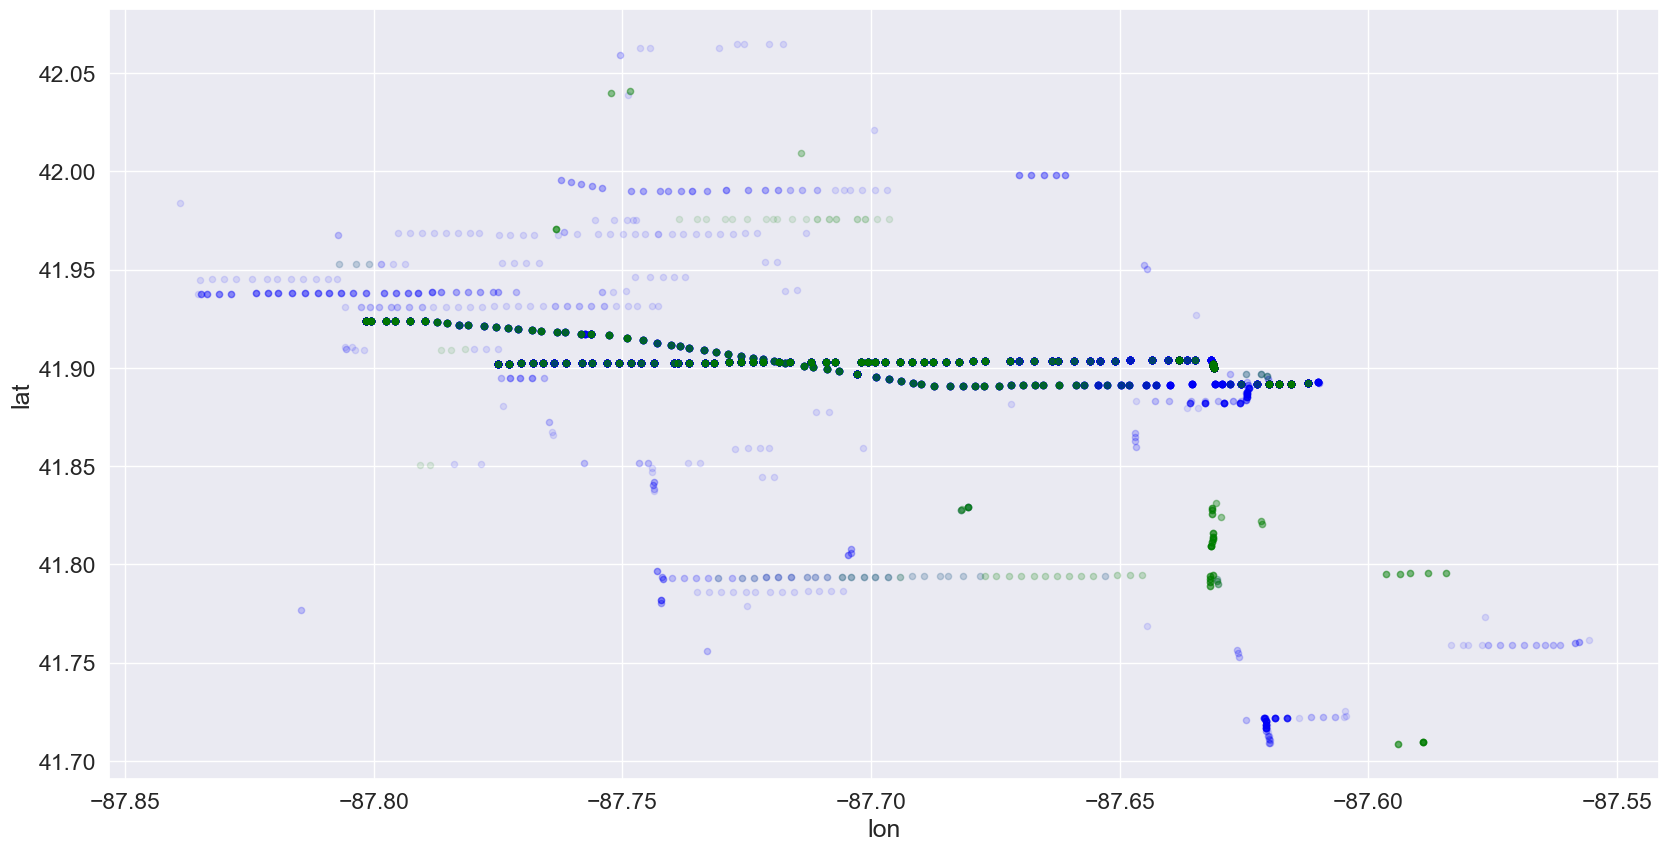

In [7]:
fig, ax = plt.subplots()
rte_full[rte_full.crt_prd == True].plot(kind = 'scatter', x='lon', y = 'lat', color = 'blue',alpha = 0.1, ax=ax)

rte_full[rte_full.crt_prd == False].plot(kind = 'scatter', x='lon', y = 'lat', color = 'green',alpha = 0.1, ax=ax)


In [8]:
rte_full['pdist'].max()

96716.0

<AxesSubplot:>

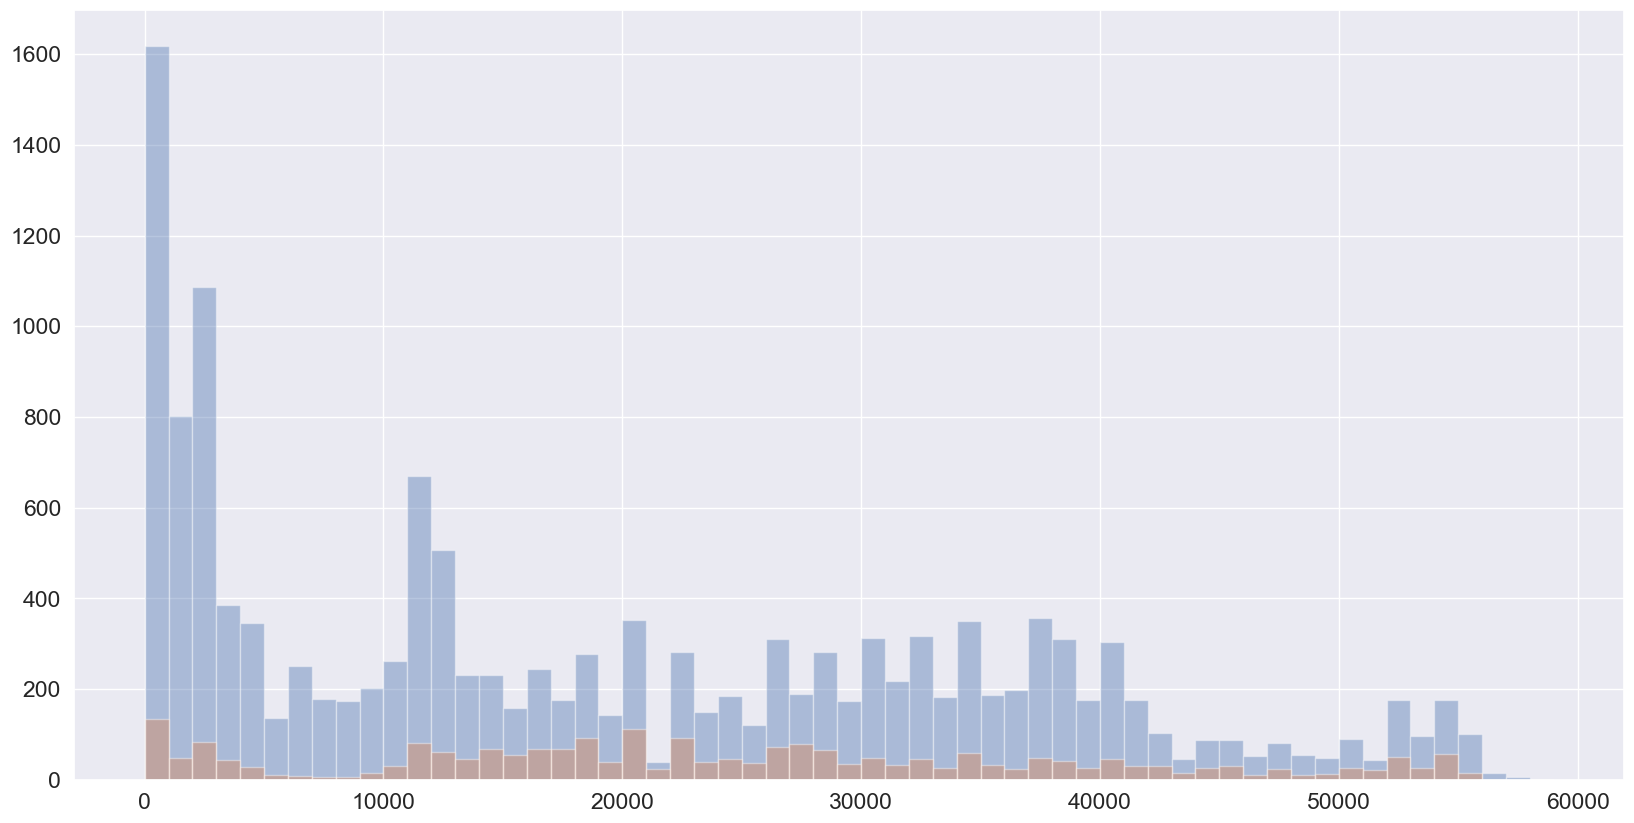

In [9]:
rte_full[rte_full.crt_prd == True].pdist.hist(bins=np.arange(0,60000, 1000),alpha = .4)
rte_full[rte_full.crt_prd == False].pdist.hist(bins=np.arange(0,60000, 1000),alpha = .4)


The graph above shows how missed predictions were distributed away from their trip origin. This shows how the majority of missed predictions took place in the middle of a route. It also appears that many of these missed time estimates were not consecutive. This theory is further strengthened by the proceeding log transformed graph.

<AxesSubplot:>

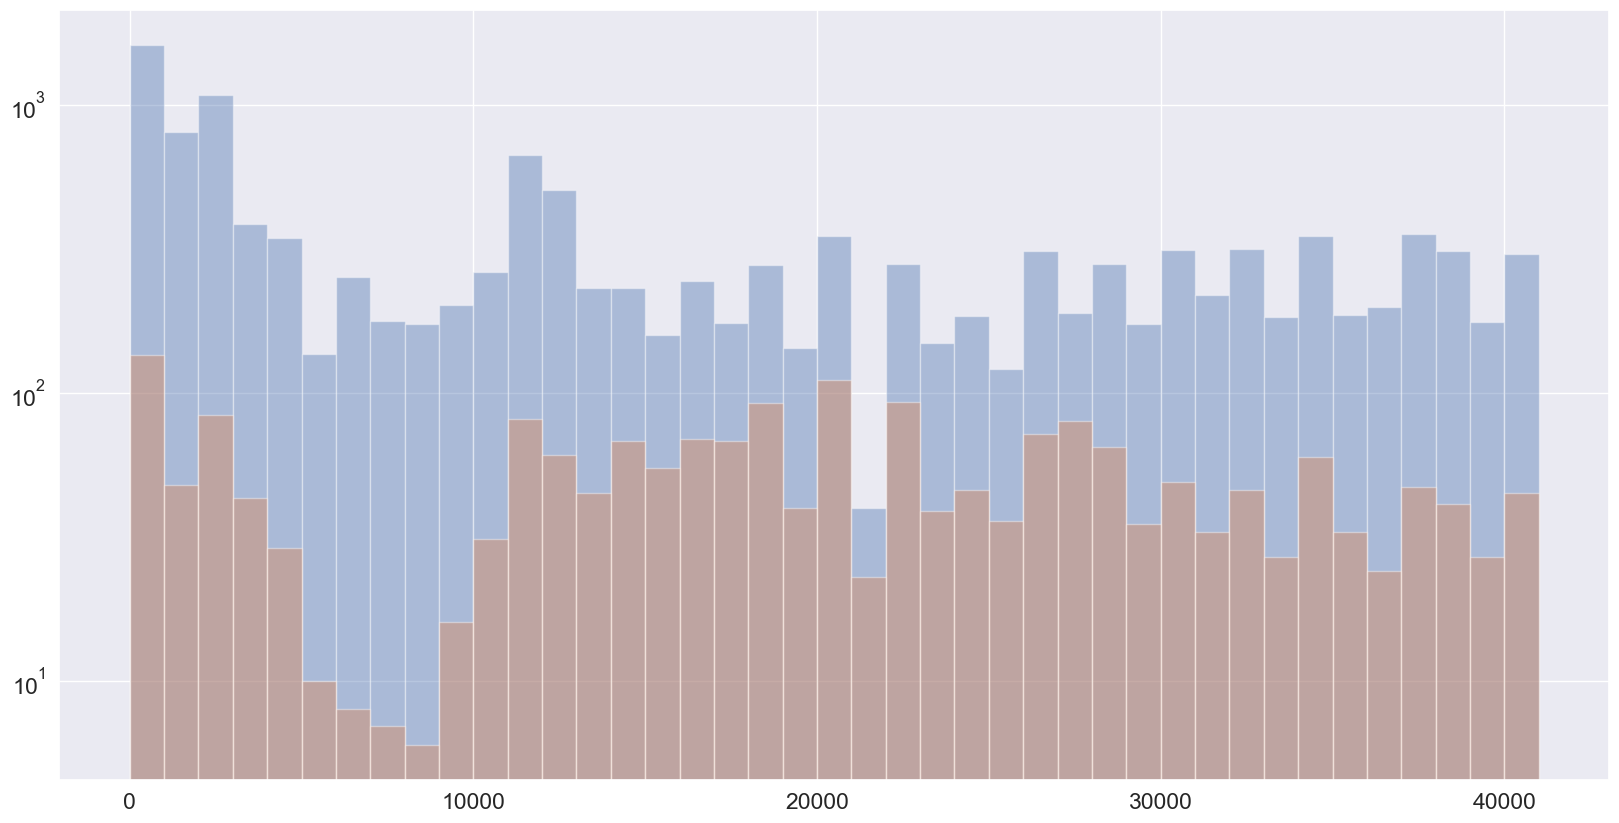

In [10]:
rte_full[rte_full.crt_prd == True].pdist.hist(bins=np.arange(0,42000, 1000),alpha = .4, log=True)
rte_full[rte_full.crt_prd == False].pdist.hist(bins=np.arange(0,42000, 1000),alpha = .4, log=True)

<AxesSubplot:>

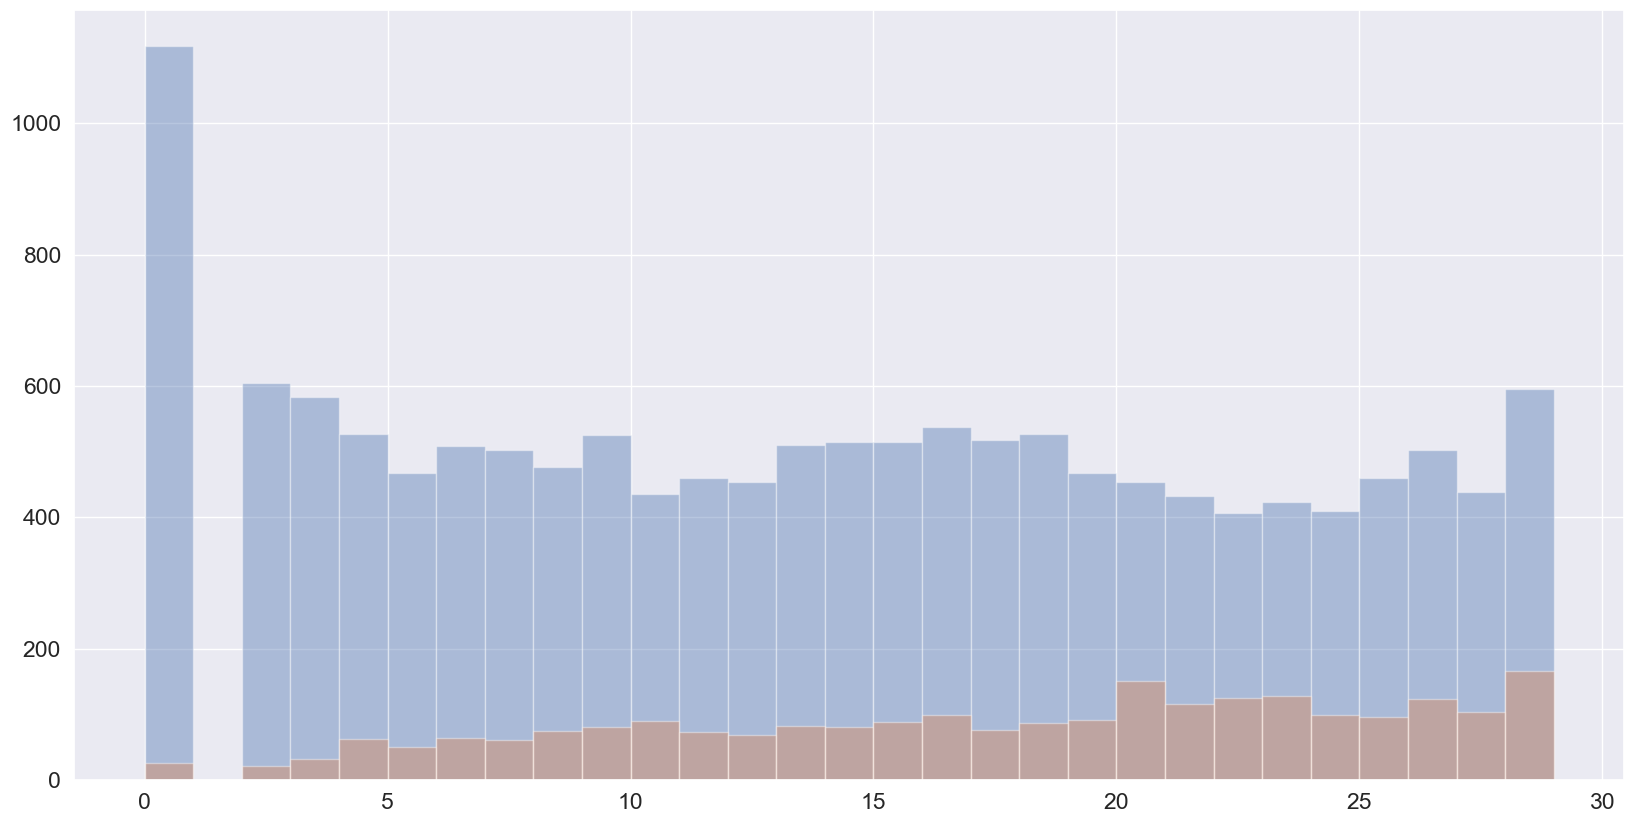

In [11]:
rte_full[rte_full.crt_prd == True].prdctdn.hist(bins=np.arange(0,30, 1),alpha = .4)
rte_full[rte_full.crt_prd == False].prdctdn.hist(bins=np.arange(0,30, 1),alpha = .4)


The graph above shows how missed predictions are distributed amoungst the original estimated arrival times. This shows how the number of missed predictions increased slightly as the estimated wait time increased.  This theory is further strengthened by the proceeding log transformed graph.

<AxesSubplot:>

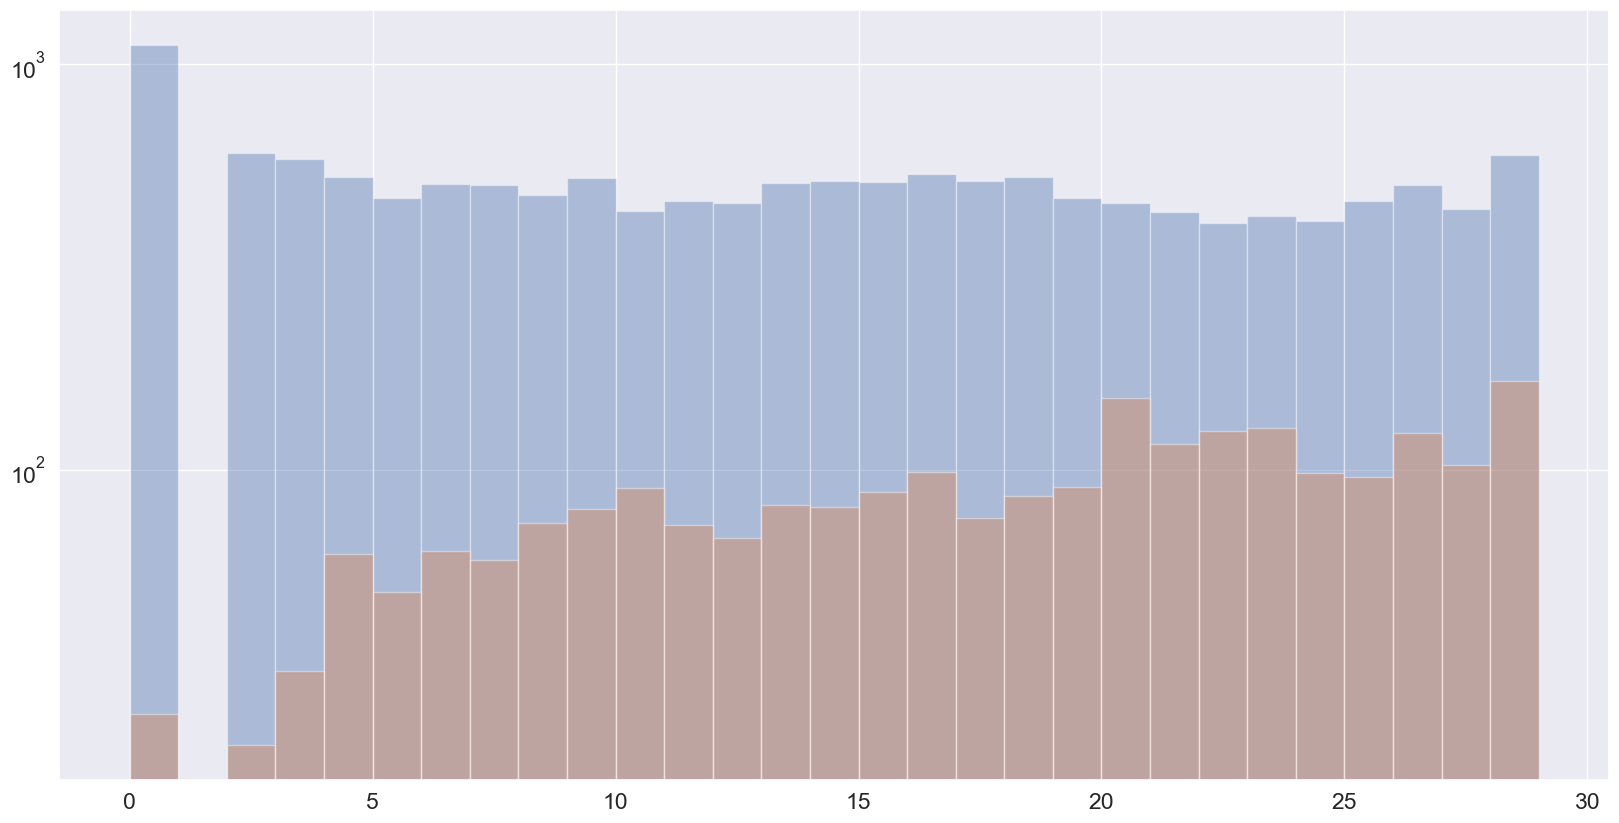

In [12]:
rte_full[rte_full.crt_prd == True].prdctdn.hist(bins=np.arange(0,30, 1),alpha = .4, log = True)
rte_full[rte_full.crt_prd == False].prdctdn.hist(bins=np.arange(0,30, 1),alpha = .4, log = True)


In [13]:
feature_cols = ['prdctdn', 'seq']#, 'lat', "lon"]
X = rte_full[feature_cols]
y = rte_full.crt_prd

model = Model()
model.fit(X,y)
rte_full['pred'] = model.predict(X)

from sklearn.metrics import accuracy_score
accuracy_score(rte_full.crt_prd, rte_full.pred.round())

0.857722382268211

Above the estimated time metric as well as the route order metric were used to build a logistic model aimed at predicting whether or not a buss would arrive on time. from this model, a new prediction column (pred) was formed to utilize this formula to predict whether or not estimates are accurate.The graph of the results hows how unliekly a false result is and the r-squared value indicates that with the data shown, busses diverting from their original arrival time may be by chance.

C:\Users\jacks\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\jacks\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


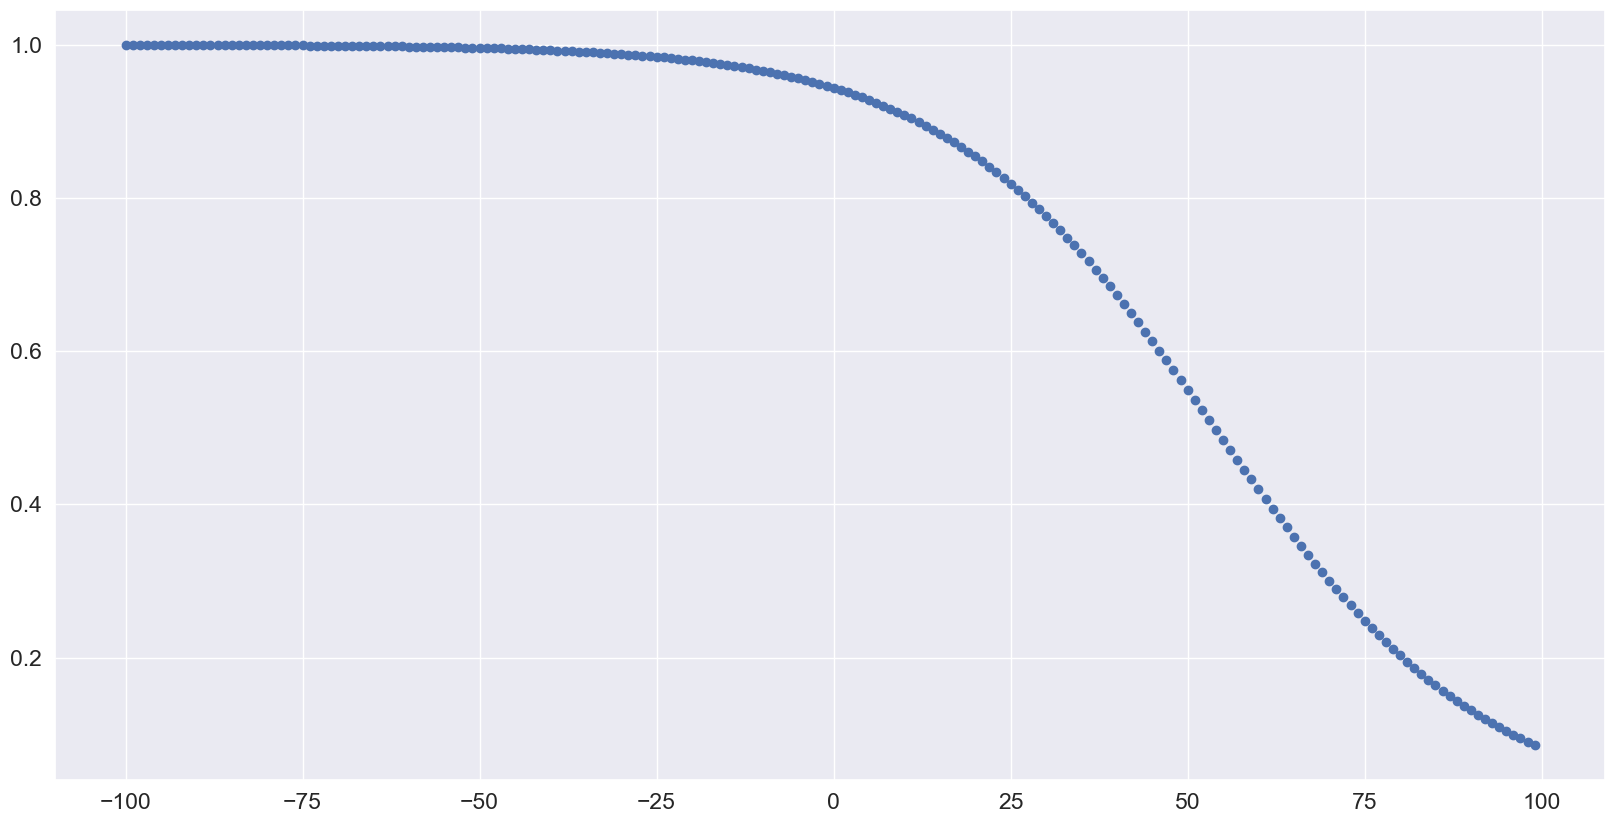

In [14]:
distances = np.arange(-100,100)
minutes = np.array([0]*200)
x_trial = np.column_stack((distances,minutes))
model.predict_proba(x_trial)
plt.scatter(distances, model.predict_proba(x_trial)[:,1])


As the graph below shows, all predictions showed estimated time being accurate. Notably, there are few routes that venture further than 6,000 feet away from their point of origin, there were no estimates where the estimated time was inaccurate.

Text(0, 0.5, 'On Time')

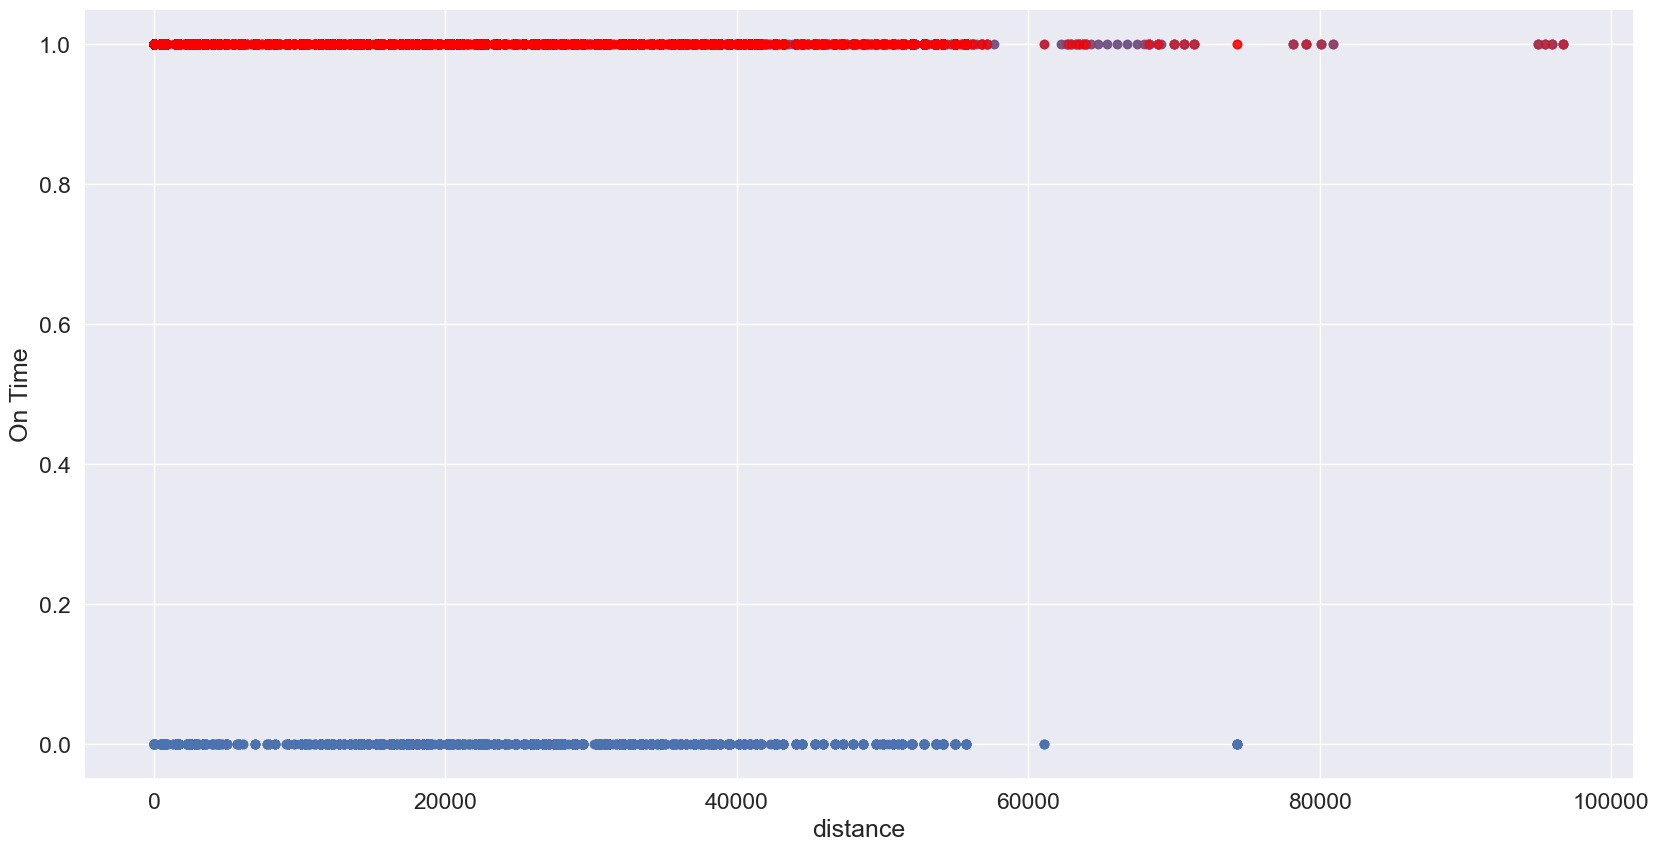

In [15]:
# scatter plot that includes the regression line
plt.scatter(rte_full.pdist, rte_full.crt_prd)
plt.scatter(rte_full.pdist, rte_full.pred, color='red', alpha=.2)
plt.xlabel('distance')
plt.ylabel('On Time')